# **TCC - PERFIS DE DESEMPENHO NO ENEM(2018–2023) EM MUNICÍPIOS DA ÁREA DE ABRANGÊNCIA DO IFNMG**

Neste segundo notebook, daremos continuidade ao trabalho iniciado na etapa de pré-processamento, onde realizamos a leitura e unificação das bases do ENEM de 2018 a 2023, aplicamos o filtro para as cidades da área de abrangência do IFNMG, removemos colunas desnecessárias, eliminamos registros de candidatos ausentes, renomeamos variáveis do questionário para facilitar a compreensão, tratamos duplicidades e inconsistências de codificação, além de compilar os dados apenas do estado de Minas Gerais e converter variáveis categóricas em ordinais. Assim, a partir dessa base já estruturada e padronizada, avançaremos agora para a etapa de aplicação de métodos estatísticos, buscando extrair interpretações relevantes sobre os candidatos e seus contextos.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

### **Realizando a leitura da base de área de abrangencia do IFNMG**

In [2]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\ENEM_RENOMEADO.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,TP_LOCALIZACAO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,1.0,Rio Pardo de Minas,1.0,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,1.0,São Francisco,1.0,...,A,A,A,B,B,A,D,A,A,B
2,2018,2,M,0.0,3,1,2,1.0,Montalvânia,1.0,...,A,A,A,B,A,A,C,A,B,B
3,2018,3,F,0.0,1,1,2,1.0,Teófilo Otoni,1.0,...,B,A,A,B,A,B,E,A,B,B
4,2018,3,M,0.0,1,1,1,1.0,Januária,2.0,...,A,A,A,C,B,A,D,B,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59749,2023,3,M,0.0,3,1,2,1.0,Pedra Azul,1.0,...,A,A,A,A,A,A,B,A,A,A
59750,2023,3,F,1.0,3,1,2,1.0,Montes Claros,1.0,...,B,A,B,B,A,B,E,A,C,B
59751,2023,4,M,1.0,1,1,2,NaN,Teófilo Otoni,1.0,...,B,A,A,A,A,A,D,A,A,B
59752,2023,2,M,1.0,3,1,2,1.0,Montes Claros,1.0,...,B,A,B,B,B,A,E,B,C,B


### **Realizando a leitura da base de MG**

In [3]:
df_mg = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_mg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **1. Comparativo das notas das escolas das cidades de abrangência do IFNMG e MG**

In [4]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

# Estatísticas para IFNMG
estat_ifnmg = pd.DataFrame({
    "Mínimo IFNMG": df_final[colunas_notas].min(),
    "Máximo IFNMG": df_final[colunas_notas].max(),
    "Média IFNMG": df_final[colunas_notas].mean(),
    "Desvio Padrão IFNMG": df_final[colunas_notas].std()
})

# Estatísticas para MG
estat_mg = pd.DataFrame({
    "Mínimo MG": df_mg[colunas_notas].min(),
    "Máximo MG": df_mg[colunas_notas].max(),
    "Média MG": df_mg[colunas_notas].mean(),
    "Desvio Padrão MG": df_mg[colunas_notas].std()
})

estatisticas_comparativas = pd.concat([estat_ifnmg, estat_mg], axis=1)

# Arredondar os valores para 1 casa decimal
estatisticas_comparativas = estatisticas_comparativas.round(1)

estatisticas_comparativas


,Mínimo IFNMG,Máximo IFNMG,Média IFNMG,Desvio Padrão IFNMG,Mínimo MG,Máximo MG,Média MG,Desvio Padrão MG
NU_NOTA_CN,0.0,799.4,484.1,74.3,0.0,869.6,509.3,81.1
NU_NOTA_CH,0.0,846.9,522.1,86.5,0.0,862.6,548.2,87.6
NU_NOTA_LC,0.0,767.3,511.1,71.1,0.0,790.8,534.1,70.7
NU_NOTA_MT,0.0,987.9,530.1,107.8,0.0,996.1,568.3,119.5
NU_NOTA_REDACAO,0.0,1000.0,570.2,217.1,0.0,1000.0,622.5,209.4


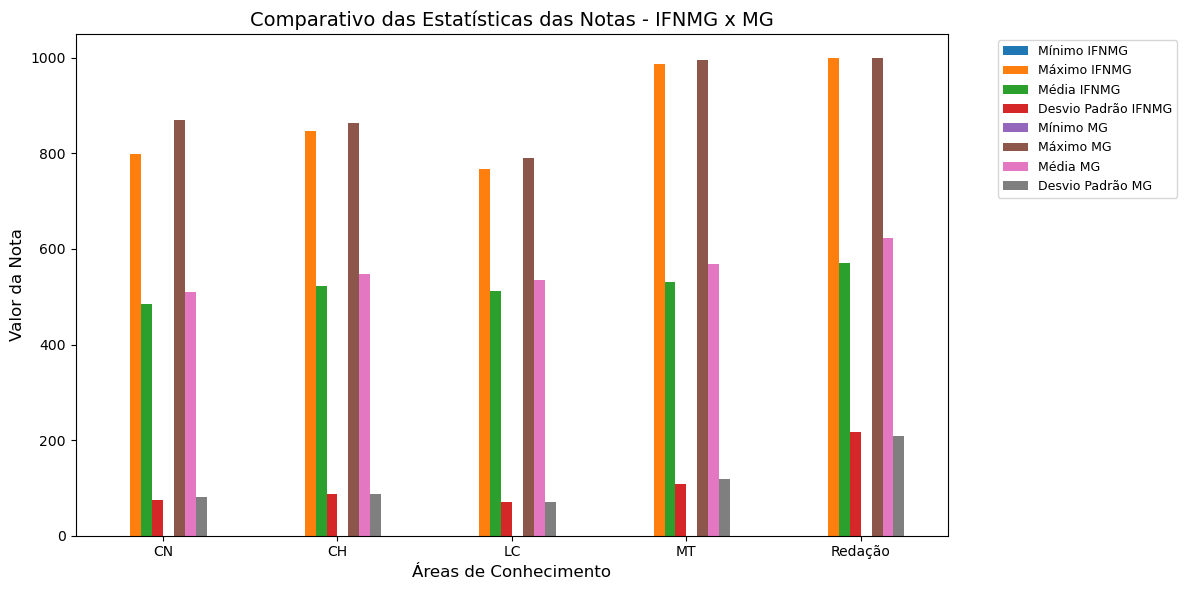

In [6]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

# Estatísticas para IFNMG
estat_ifnmg = pd.DataFrame({
    "Mínimo IFNMG": df_final[colunas_notas].min(),
    "Máximo IFNMG": df_final[colunas_notas].max(),
    "Média IFNMG": df_final[colunas_notas].mean(),
    "Desvio Padrão IFNMG": df_final[colunas_notas].std()
})

# Estatísticas para MG
estat_mg = pd.DataFrame({
    "Mínimo MG": df_mg[colunas_notas].min(),
    "Máximo MG": df_mg[colunas_notas].max(),
    "Média MG": df_mg[colunas_notas].mean(),
    "Desvio Padrão MG": df_mg[colunas_notas].std()
})

# Juntando as duas
estatisticas = pd.concat([estat_ifnmg, estat_mg], axis=1).round(1)

# ---------- VISUALIZAÇÃO ----------
estatisticas.plot(kind="bar", figsize=(12, 6))

plt.title("Comparativo das Estatísticas das Notas - IFNMG x MG", fontsize=14)
plt.xlabel("Áreas de Conhecimento", fontsize=12)
plt.ylabel("Valor da Nota", fontsize=12)
plt.xticks(range(len(colunas_notas)), ["CN", "CH", "LC", "MT", "Redação"], rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()



### **2. Comparativo das notas 0 para o IFNMG e MG**

🔹 Comparativo de notas zeradas:


,Qtd IFNMG,% IFNMG,Qtd MG,% MG
NU_NOTA_CN,35,0.06,270,0.05
NU_NOTA_CH,95,0.16,539,0.10
NU_NOTA_LC,42,0.07,242,0.05
NU_NOTA_MT,35,0.06,276,0.05
NU_NOTA_REDACAO,2597,4.35,11571,2.23


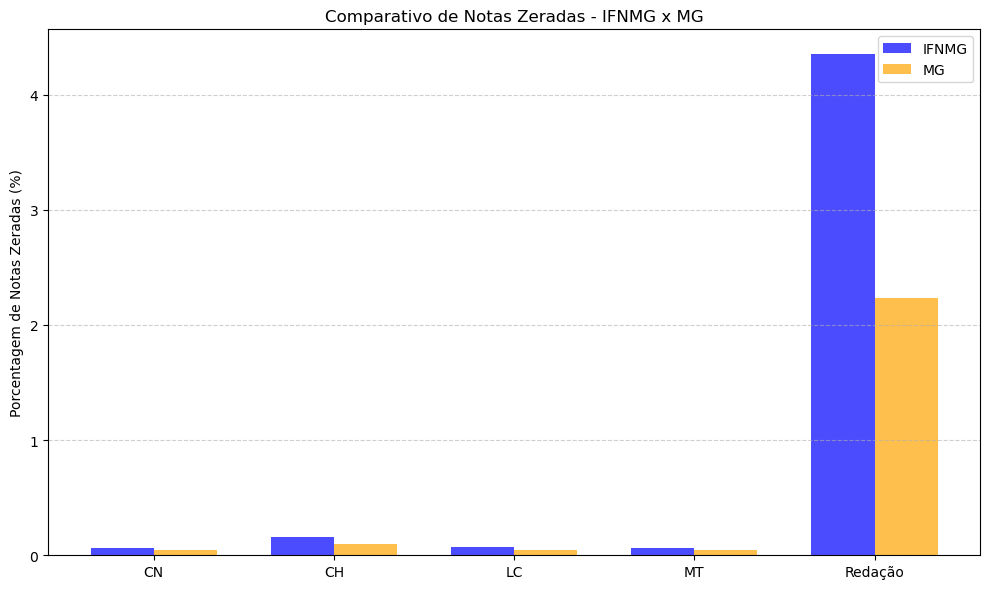

In [8]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

# ================== IFNMG ==================
total_ifnmg = len(df_final)
qtd_zeros_ifnmg = (df_final[colunas_notas] == 0).sum()
porcent_zeros_ifnmg = (qtd_zeros_ifnmg / total_ifnmg * 100).round(2)

# ================== MG ==================
total_mg = len(df_mg)
qtd_zeros_mg = (df_mg[colunas_notas] == 0).sum()
porcent_zeros_mg = (qtd_zeros_mg / total_mg * 100).round(2)

# ================== TABELA COMPARATIVA ==================
tabela_zeros = pd.DataFrame({
    "Qtd IFNMG": qtd_zeros_ifnmg,
    "% IFNMG": porcent_zeros_ifnmg,
    "Qtd MG": qtd_zeros_mg,
    "% MG": porcent_zeros_mg
}).round(2)

print("🔹 Comparativo de notas zeradas:")
display(tabela_zeros)

# ================== GRÁFICO ==================
plt.figure(figsize=(10,6))

# gráfico de barras duplas (porcentagem)
x = range(len(colunas_notas))
largura = 0.35

plt.bar([i - largura/2 for i in x], porcent_zeros_ifnmg, width=largura, label='IFNMG', color='blue', alpha=0.7)
plt.bar([i + largura/2 for i in x], porcent_zeros_mg, width=largura, label='MG', color='orange', alpha=0.7)

plt.xticks(x, ["CN", "CH", "LC", "MT", "Redação"])
plt.ylabel("Porcentagem de Notas Zeradas (%)")
plt.title("Comparativo de Notas Zeradas - IFNMG x MG")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


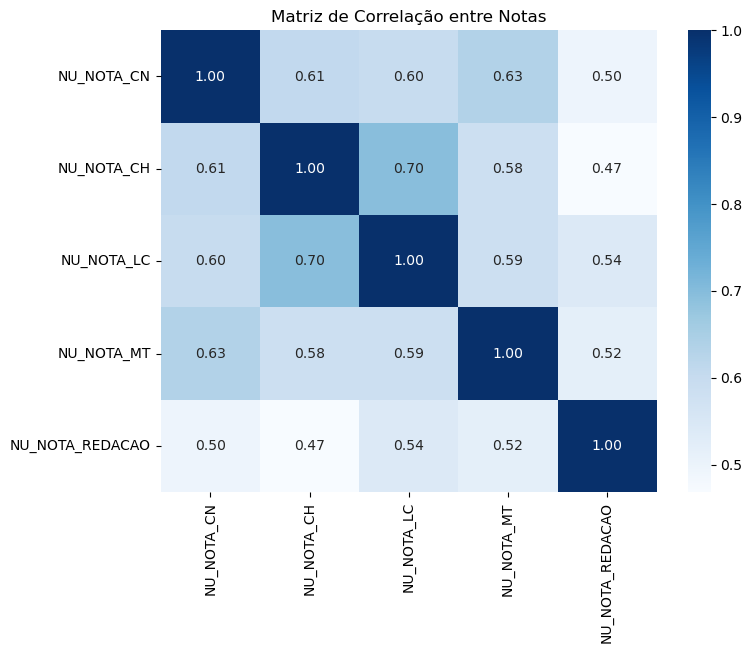

✅ Correlação não é tão alta, mantidas as notas originais.


In [17]:
notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

# 1. Selecionar apenas as notas
df_notas = df_final[notas]

# 2. Criar a matriz de correlação
corr = df_notas.corr()

# 3. Visualizar com mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de Correlação entre Notas")
plt.show()

# 4. Verificar se a correlação é alta
limite = 0.85
mask = (abs(corr) > limite) & (corr != 1.0)

if mask.any().any():
    print("⚠️ Há correlação alta entre as notas.")
    # Criar nota geral (média das notas)
    df["NOTA_GERAL"] = df_notas.mean(axis=1)
    # Remover notas individuais
    df = df.drop(columns=notas)
else:
    print("✅ Correlação não é tão alta, mantidas as notas originais.")
